In [1]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt
from utils import *

In [2]:
# load kinetic BH info at scale factor 1.0 (redshift 0)
# load as a dictionary
kBHinfo = dict(np.load('kbhinfo_kn1-DF_z2.0.npz'))

In [3]:
kBHinfo['BHID']

array([268203233, 277193935, 277611223, 286622413, 286884954, 301842231,
       386919457, 505128994, 507171232, 509216051, 519002391, 522739847,
       523093245], dtype=uint64)

In [4]:
kBHinfo.keys()

dict_keys(['BHID', 'BHMass', 'FirstReleaseTime', 'FirstReleaseMass', 'ReleasedKE', 'EndTime', 'SwallowID'])

In [5]:
kBHinfo['EndTime'].sort()

In [6]:
kBHinfo['EndTime'][-100:]

array([0.33330824, 0.33330824, 0.33332706, 0.33333019, 0.33333019,
       0.33333019, 0.33333019, 0.33333019, 0.33333019, 0.33333019,
       0.33333019, 0.33333019, 0.33333019])

In [7]:
0.8333312944113008 - 0.8333333

-2.005588699227623e-06

In [8]:
0.83333129-.833333

-1.710000000043621e-06

In [9]:
0.83333333-.833333

3.29999999992836e-07

In [10]:
# unit conversion
# f_mass = 1e10  # 1e10 Msun/h to Msun/h
# f_energy = 1e10 * (1e5)**2 * 1.989e33  # 1e10 Msun/h *(km/s)^2 to erg/h
# c_kmps = 3e5  # speed of light in km/s
# f_energy_in_mass = 1e10 / (c_kmps)**2  # 1e10 Msun/h *(km/s)^2 to Msun/h * c^2  (E=mc^2)
# kBHinfo['ActivationMass'] *= f_mass  # to Msun/h
# kBHinfo['BHMass'] *= f_mass  # to Msun/h
# # kBHinfo['ReleasedKE'] *= f_energy  # to erg/h
# kBHinfo['ReleasedKE'] *= f_energy_in_mass  # to Msun/h * c^2

def convert_units(data_dict):
    f_mass = 1e10  # 1e10 Msun/h to Msun/h
    f_energy = 1e10 * (1e5)**2 * 1.989e33  # 1e10 Msun/h *(km/s)^2 to erg/h
    c_kmps = 3e5  # speed of light in km/s
    f_energy_in_mass = 1e10 / (c_kmps)**2  # 1e10 Msun/h *(km/s)^2 to Msun/h * c^2  (E=mc^2)
    data_dict['FirstReleaseMass'] *= f_mass  # to Msun/h
    data_dict['BHMass'] *= f_mass
    data_dict['ReleasedKE'] *= f_energy_in_mass  # to Msun/h * c^2

    return data_dict



In [11]:
def plot_with_percentiles(ax, x, y, xbins=30, color='blue', xlower=None, xupper=None):
    # define bins in logarithmic space
    if xlower is None:
        xlower = np.min(x)
    if xupper is None:
        xupper = np.max(x)
    x_edges = np.logspace(np.log10(xlower), np.log10(xupper), xbins+1)
    x_centers = np.sqrt(x_edges[:-1] * x_edges[1:])

    y_median = []
    y_p16 = []  # 16th percentile in log space
    y_p84 = []

    for i in range(xbins):
        mask = (x >= x_edges[i]) & (x < x_edges[i+1])
        if np.sum(mask) > 0:
            y_bin = y[mask]
            y_median.append(np.median(y_bin))
            y_p16.append(np.percentile(y_bin, 16))
            y_p84.append(np.percentile(y_bin, 84))
        else:
            y_median.append(np.nan)
            y_p16.append(np.nan)
            y_p84.append(np.nan)

    y_median = np.array(y_median)
    y_p16 = np.array(y_p16)
    y_p84 = np.array(y_p84)
    ax.plot(x_centers, y_median, linestyle='-', color=color, label='Median')
    # print(f"Median y values: {y_median}")
    ax.fill_between(x_centers, y_p16, y_p84, color=color, alpha=0.3, label='16th-84th Percentile')
    


In [12]:
def get_kBH_end(filename, all_feedback=True, released_only=True):
    kBHinfo = dict(np.load(filename))
    if all_feedback:
        kBHinfo = get_kBHinfo_all_feedback(kBHinfo)
    mask = kBHinfo['EndTime'] == kBHinfo['EndTime'].max()
    kBHinfo = {key: val[mask] for key, val in kBHinfo.items()}
    if released_only:
        # retain only those that released feedback energy
        mask_feedback = kBHinfo['ReleasedKE'] > 0
        kBHinfo = {key: val[mask_feedback] for key, val in kBHinfo.items()}
    # convert units
    kBHinfo = convert_units(kBHinfo)
    return kBHinfo

In [13]:
def get_kBHinfo_all_feedback(kBHinfo):
    """
    Get the total feedback energy released by the primary BH and all its swallowed BHs by the target end time (the max).
    """
    # sort by EndTime to ensure primary BHs come after their swallowed BHs
    sort_indices = np.argsort(kBHinfo['EndTime'])
    kBHinfo_sorted = {key: val[sort_indices] for key, val in kBHinfo.items()}

    # add the feedback energy from swallowed BHs to their primary BHs, until the target end time
    for i in range(len(kBHinfo_sorted['BHID'])):
        # stop when reaching the target end time
        if kBHinfo_sorted['EndTime'][i] == kBHinfo_sorted['EndTime'][-1]:
            break
        # skip if the BH has not released any feedback energy
        if kBHinfo_sorted['ReleasedKE'][i] <= 0:
            continue

        swallower_id = kBHinfo_sorted['SwallowID'][i]

        # add the feedback energy to the swallower BH if it exists
        idx_swallower = np.where(kBHinfo_sorted['BHID'] == swallower_id)[0]
        if len(idx_swallower) > 0:
            idx_swallower = idx_swallower[0]
            # print message if the swallower BH has not released any feedback energy yet
            if kBHinfo_sorted['ReleasedKE'][idx_swallower] <= 0:
                print(f"Info: Swallower BHID {swallower_id} has not released feedback energy yet") # this is possible but rare
            kBHinfo_sorted['ReleasedKE'][idx_swallower] += kBHinfo_sorted['ReleasedKE'][i]
        else:
            print(f"Warning: Swallower BHID {swallower_id} not found for BHID {kBHinfo_sorted['BHID'][i]}") # this should not happen
            # print end time
            print(f"EndTime of this BH: {kBHinfo_sorted['EndTime'][i]}")

    # we only need the primary BHs at the target end time
    mask_primary = kBHinfo_sorted['EndTime'] == kBHinfo_sorted['EndTime'][-1]
    kBHinfo_allfdbk = {key: val[mask_primary] for key, val in kBHinfo_sorted.items()}
    return kBHinfo_allfdbk



    

In [14]:
kBHinfo = convert_units(kBHinfo)
# keep only BHs that exist at z=0 (i.e., the primary BHs survived merging events)
mask = kBHinfo['EndTime'] == 1 

kBHinfo_primary = {key: val[mask] for key, val in kBHinfo.items()}
# if keep only BHs that released feedback energy
mask_feedback = kBHinfo_primary['ReleasedKE'] > 0
kBHinfo_primary = {key: val[mask_feedback] for key, val in kBHinfo_primary.items()}

# take into account also the feedback energy released by BHs that have been swallowed by the primary BHs
kBHinfo_allfdbk = get_kBHinfo_all_feedback(kBHinfo)
# keep only BHs that released feedback energy
mask_feedback_all = kBHinfo_allfdbk['ReleasedKE'] > 0
kBHinfo_allfdbk = {key: val[mask_feedback_all] for key, val in kBHinfo_allfdbk.items()}

In [15]:
kBHinfo_allfdbk = get_kBH_end('kbhinfo_kn1-DF_z2.0.npz')

EndTime of this BH: 0.333308241319652
EndTime of this BH: 0.333308241319652
EndTime of this BH: 0.3333270576528747


In [16]:
# z_cut = 2.3

# kBHinfo_cut = dict(np.load('kbhinfo_kn1-DF_z2.0.npz'))
# kBHinfo_cut = convert_units(kBHinfo_cut)
# mask_cut = kBHinfo_cut['EndTime'] == kBHinfo_cut['EndTime'][-1] # kBHinfo_cut['EndTime'].max()
# kBHinfo_cut_primary = {key: val[mask_cut] for key, val in kBHinfo_cut.items()}
# # retain only those that released feedback energy
# mask_cut_feedback = kBHinfo_cut_primary['ReleasedKE'] > 0
# kBHinfo_cut_primary = {key: val[mask_cut_feedback] for key, val in kBHinfo_cut_primary.items()}



kBHinfo_cut_primary = get_kBH_end('kbhinfo_kn1-DF_z2.0.npz', all_feedback=False)

In [17]:
kBHinfo_cut_primary['ReleasedKE'].shape

(0,)

In [18]:
kBHinfo_cut_primary['BHMass']

array([], dtype=float64)

In [19]:
kBHinfo_cut_primary['ReleasedKE'].max()

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
kBHinfo_cut_primary['ReleasedKE']

array([208841.19141856])

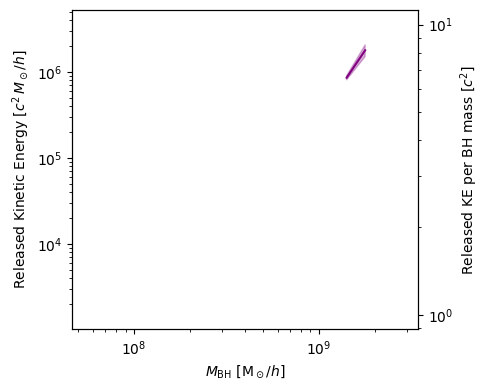

In [ ]:


fig, ax = plt.subplots(figsize=(5, 4))

# left axis: kinetic energy
# plot_with_percentiles(
#     ax,
#     kBHinfo_primary['BHMass'],
#     kBHinfo_primary['ReleasedKE'],
#     xbins=30,
#     color='blue'
# )

# plot_with_percentiles(
#     ax,
#     kBHinfo_cut_primary['BHMass'],
#     kBHinfo_cut_primary['ReleasedKE'],
#     xbins=30,
#     color='orange'
# )

# all feedback energy including swallowed BHs
plot_with_percentiles(
    ax,
    kBHinfo_allfdbk['BHMass'],
    kBHinfo_allfdbk['ReleasedKE'],
    xbins=30,
    color='purple',
    xlower=1e7,
    xupper=1e10
)

# plot_with_percentiles(
#     ax,
#     kBHinfo['BHMass'],
#     kBHinfo['ReleasedKE'],
#     xbins=30,
#     color='orange'
# )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_\mathrm{BH}$ [M$_\odot/h$]')
ax.set_ylabel(r'Released Kinetic Energy [$c^2\,M_\odot/h$]')

# right axis
ax2 = ax.twinx()
# ax2.set_yscale('log')

# example: same data but different units / transformation
z_activation = 1.0 / kBHinfo_primary['FirstReleaseTime'] - 1.0
# plot_with_percentiles(
#     ax2,
#     kBHinfo_primary['BHMass'],
#     z_activation,
#     xbins=50,
#     color='red'
# )

# activation mass
# plot_with_percentiles(
#     ax2,
#     kBHinfo_primary['BHMass'],
#     kBHinfo_primary['FirstReleaseMass'],
#     xbins=30,
#     color='green'
# )
ax2.set_yscale('log')

ax2.set_ylabel(r'Released KE per BH mass [$c^2$]')

plt.tight_layout()
plt.show()

In [ ]:
# # function to plot energy density distribution
# def plot_energy_density_distribution(ax, kBHinfo, nbins=50, m_lower=1e7, m_upper=1e10, volume=50**3):
#     # bins in log space
#     mbins = np.logspace(np.log10(m_lower), np.log10(m_upper), nbins+1)
#     de, _ = np.histogram(kBHinfo['BHMass'], weights=kBHinfo['ReleasedKE'], bins=mbins)
#     # energy density distribution
#     du_dlogm = de / volume / np.diff(np.log10(mbins))  # [c^2 Msun/h / (Mpc/h)^3]

#     mbin_centers = np.sqrt(mbins[:-1] * mbins[1:])
#     # cut the leading and trailing zeros for better visualization
#     nonzero_mask = du_dlogm > 0
#     mbin_centers = mbin_centers[nonzero_mask]
#     du_dlogm = du_dlogm[nonzero_mask]
#     ax.plot(mbin_centers, du_dlogm)

Total energy density (from 1.0e+07 to 1.0e+10 Msun/h): 0.000e+00 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+07 to 1.0e+10 Msun/h): 7.747e+01 c^2 Msun/h / (Mpc/h)^3


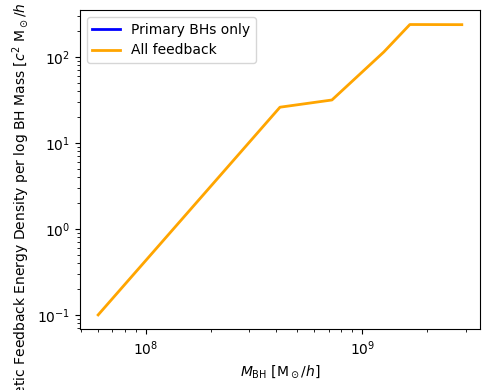

In [ ]:
# feedback energy density of distribution over BH mass

fig, ax = plt.subplots(figsize=(5, 4))

plot_energy_density_distribution(ax, kBHinfo_primary, nbins=25, xlower=1e7, xupper=1e10, volume=50**3, label='Primary BHs only')
# all feedback energy including swallowed BHs
plot_energy_density_distribution(ax, kBHinfo_allfdbk, nbins=25, xlower=1e7, xupper=1e10, volume=50**3, label='All feedback', color='orange')

ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_\mathrm{BH}$ [M$_\odot/h$]')
ax.set_ylabel(r'Kinetic Feedback Energy Density per log BH Mass [$c^2$ M$_\odot/h$ / (Mpc/h)$^3$]')
plt.tight_layout()
plt.show()

